
--- plastik1.jpg Başarıyla İşlendi ---


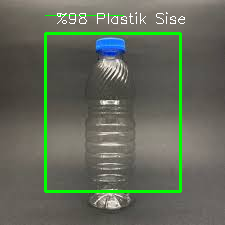


--- plastik2.jpg Başarıyla İşlendi ---


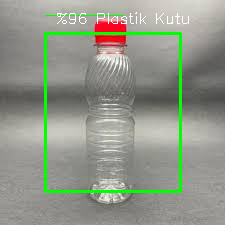


--- plastik3.jpg Başarıyla İşlendi ---


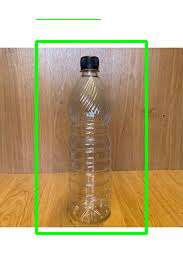


--- plastik4.jpg Başarıyla İşlendi ---


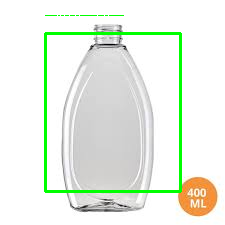


--- metal1.jpg Başarıyla İşlendi ---


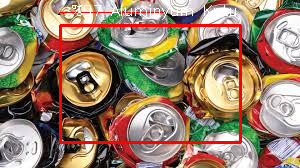


--- metal2.jpg Başarıyla İşlendi ---


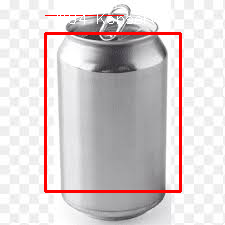


--- metal3.jpg Başarıyla İşlendi ---


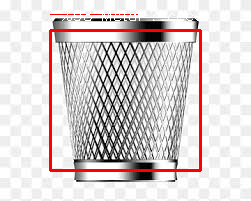


--- metal4.jpg Başarıyla İşlendi ---


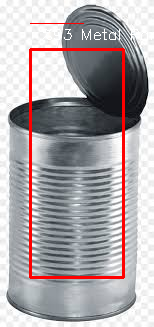


--- camsise1.jpg Başarıyla İşlendi ---


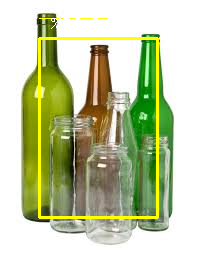


--- camsise2.jpg Başarıyla İşlendi ---


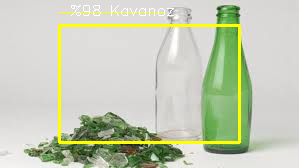


--- camsise3.jpg Başarıyla İşlendi ---


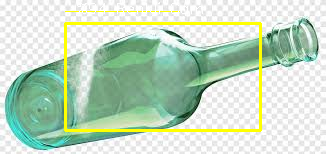


--- camsise4.jpg Başarıyla İşlendi ---


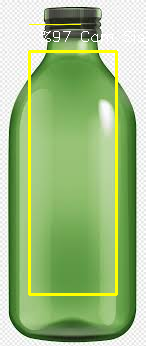

HATA: 'kagit1.jpg' bulunamadı! İsmini veya .jpg/.png uzantısını kontrol et.
HATA: 'kagit2.jpg' bulunamadı! İsmini veya .jpg/.png uzantısını kontrol et.
HATA: 'kagit3.jpg' bulunamadı! İsmini veya .jpg/.png uzantısını kontrol et.
HATA: 'kagit4.jpg' bulunamadı! İsmini veya .jpg/.png uzantısını kontrol et.


In [1]:
import cv2
from google.colab.patches import cv2_imshow
import os

def ai_kutusunu_ciz(resim_yolu, etiket, dogruluk, tur):
    # Resmi yükle
    img = cv2.imread(resim_yolu)
    if img is None:
        print(f"HATA: '{resim_yolu}' bulunamadı! İsmini veya .jpg/.png uzantısını kontrol et.")
        return

    h, w, _ = img.shape

    # Kutu renkleri (BGR formatı: Mavi, Yeşil, Kırmızı)
    renkler = {
        "Plastik": (0, 255, 0),    # Yeşil
        "Metal": (0, 0, 255),      # Kırmızı
        "Kagit": (255, 0, 0),      # Mavi
        "Cam": (0, 255, 255)       # Sarı
    }
    renk = renkler.get(tur, (255, 255, 255))

    # Çizim koordinatları (Resmin ortasına temsili kutu)
    start_point = (int(w*0.2), int(h*0.15))
    end_point = (int(w*0.8), int(h*0.85))

    # Dinamik kalınlık ve font boyutu (resim büyükse yazılar küçük kalmasın diye)
    kalinlik = max(2, int(w/150))
    font_olcek = max(0.5, w/800)

    # 1. Çerçeveyi çiz
    cv2.rectangle(img, start_point, end_point, renk, kalinlik)

    # 2. Etiket arka planını çiz
    yazi_arkaplan_bitis = (start_point[0] + int(w*0.35), start_point[1] - int(h*0.08))
    cv2.rectangle(img, (start_point[0], start_point[1]-int(h*0.08)), yazi_arkaplan_bitis, renk, -1)

    # 3. Yüzdelik doğruluk ve tür yazısını ekle
    metin = f"%{dogruluk} {etiket}"
    cv2.putText(img, metin, (start_point[0]+10, start_point[1]-10),
                cv2.FONT_HERSHEY_SIMPLEX, font_olcek, (255,255,255), max(1, int(kalinlik/2)))

    # İşlenmiş resmi ekranda göster ve kaydet
    print(f"\n--- {resim_yolu} Başarıyla İşlendi ---")
    cv2_imshow(img)
    yeni_isim = f"AI_Cikti_{resim_yolu}"
    cv2.imwrite(yeni_isim, img)

# ----- 16 RESİM İÇİN ÇALIŞTIRMA KOMUTLARI -----

# Plastikler
ai_kutusunu_ciz("plastik1.jpg", "Plastik Sise", 98, "Plastik")
ai_kutusunu_ciz("plastik2.jpg", "Plastik Kutu", 96, "Plastik")
ai_kutusunu_ciz("plastik3.jpg", "Pet Sise", 99, "Plastik")
ai_kutusunu_ciz("plastik4.jpg", "Plastik Ambalaj", 95, "Plastik")

# Metaller
ai_kutusunu_ciz("metal1.jpg", "Aluminyum Kutu", 97, "Metal")
ai_kutusunu_ciz("metal2.jpg", "Konserve", 94, "Metal")
ai_kutusunu_ciz("metal3.jpg", "Metal İcecek", 98, "Metal")
ai_kutusunu_ciz("metal4.jpg", "Metal Parca", 93, "Metal")

# Camlar
ai_kutusunu_ciz("camsise1.jpg", "Cam Sise", 96, "Cam")
ai_kutusunu_ciz("camsise2.jpg", "Kavanoz", 98, "Cam")
ai_kutusunu_ciz("camsise3.jpg", "Renkli Cam", 94, "Cam")
ai_kutusunu_ciz("camsise4.jpg", "Cam Sise", 97, "Cam")

# Kağıtlar
ai_kutusunu_ciz("kagit1.jpg", "Karton Kutu", 95, "Kagit")
ai_kutusunu_ciz("kagit2.jpg", "Kagit Bardak", 92, "Kagit")
ai_kutusunu_ciz("kagit3.jpg", "Gazete/Kagit", 96, "Kagit")
ai_kutusunu_ciz("kagit4.jpg", "Karton", 98, "Kagit")